# Business question: How can movie sales/success be predicted based on the language of reviews, the marketing aspects, and movie production elements?

# Suggested sub questions:
Language of Reviews: Can the sentiment and semantic themes (extracted via Transformer embeddings) from expert and user reviews accurately predict the box office tier of a movie?

Marketing Aspects: To what extent do the number of theaters and "opening weekend" performance correlate with long-term international box office success?

Production Elements: Which production features (Genre, Runtime, Rating, and Studio) are the strongest predictors of a movie’s financial success?

Model Performance: Which model (Baseline, Random Forest, or Neural Network) provides the highest accuracy in predicting movie success using these combined features?

In [33]:
# Uploading the libraries that we need

import pandas as pd # for data manipulaion
import seaborn as sns # for visualization
import matplotlib.pyplot as plt # for visualization
import numpy as np # for computation
import re # to work with regular expressions
from sklearn.impute import KNNImputer # to be used for KNN (runtime imputation)

In [34]:
# Importing the dataset from source files

df_sales = pd.read_excel(r"D:\DDB Master's\Ai for business\GiT-hub 2025\Metacritic dataset\sales.xlsx")
df_meta = pd.read_excel(r"D:\DDB Master's\Ai for business\GiT-hub 2025\Metacritic dataset\metaClean43Brightspace.xlsx")
df_user = pd.read_excel(r"D:\DDB Master's\Ai for business\GiT-hub 2025\Metacritic dataset\UserReviews.xlsx")
df_expert = pd.read_excel(r"D:\DDB Master's\Ai for business\GiT-hub 2025\Metacritic dataset\ExpertReviews.xlsx")

In [35]:
# Check our data frames and data types.

df_sales.info()
df_meta.info()
df_user.info()
df_expert.info()

# df_sales.tale(10) # just to check 
# df_sales.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30612 entries, 0 to 30611
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      30612 non-null  int64  
 1   release_date              30612 non-null  object 
 2   title                     30604 non-null  object 
 3   genre                     28908 non-null  object 
 4   international_box_office  21575 non-null  float64
 5   domestic_box_office       11884 non-null  float64
 6   worldwide_box_office      21575 non-null  float64
 7   production_budget         4480 non-null   float64
 8   Unnamed: 8                0 non-null      float64
 9   opening_weekend           10929 non-null  float64
 10  theatre_count             10963 non-null  float64
 11  avg run per theatre       10952 non-null  float64
 12  runtime                   24559 non-null  float64
 13  keywords                  12517 non-null  object 
 14  creati

In [36]:
df_sales.head(3)

,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url
0,2000,January 1st,Bakha Satang,Drama,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,NaN,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2001,January 12th,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,NaN,5486209.0,2433.0,3.1,NaN,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,2000,January 28th,Santitos,NaN,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos


In [37]:
df_sales.shape

(30612, 16)

In [38]:
df_sales.dtypes

year                          int64
release_date                 object
title                        object
genre                        object
international_box_office    float64
domestic_box_office         float64
worldwide_box_office        float64
production_budget           float64
Unnamed: 8                  float64
opening_weekend             float64
theatre_count               float64
avg run per theatre         float64
runtime                     float64
keywords                     object
creative_type                object
url                          object
dtype: object

In [39]:
df_sales.describe()

,year,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime
count,30612.000000,2.157500e+04,1.188400e+04,2.157500e+04,4.480000e+03,0.0,1.092900e+04,10963.000000,10952.000000,24559.000000
mean,2014.542108,1.586202e+07,1.735331e+07,2.524796e+07,3.642238e+07,NaN,5.488562e+06,723.147040,4.124562,101.502993
std,5.525085,6.659680e+07,5.050972e+07,1.009796e+08,4.644049e+07,NaN,1.633207e+07,1246.401636,3.423855,27.194334
min,2000.000000,2.000000e+00,2.000000e+01,2.000000e+00,1.100000e+03,NaN,1.100000e+01,1.000000,0.000000,11.000000
25%,2012.000000,2.637500e+04,2.986550e+04,3.422900e+04,6.500000e+06,NaN,7.352000e+03,2.000000,2.000000,89.000000
50%,2016.000000,3.348470e+05,2.587510e+05,4.753220e+05,2.000000e+07,NaN,4.087500e+04,8.000000,3.400000,97.000000
75%,2019.000000,4.282312e+06,7.667212e+06,6.302152e+06,4.500000e+07,NaN,2.150979e+06,969.500000,5.400000,110.000000
max,2021.000000,2.085392e+09,9.366622e+08,2.845900e+09,4.000000e+08,NaN,3.571150e+08,4725.000000,88.400000,2020.000000


In [40]:
df_sales.isna().sum()

year                            0
release_date                    0
title                           8
genre                        1704
international_box_office     9037
domestic_box_office         18728
worldwide_box_office         9037
production_budget           26132
Unnamed: 8                  30612
opening_weekend             19683
theatre_count               19649
avg run per theatre         19660
runtime                      6053
keywords                    18095
creative_type                3945
url                             0
dtype: int64

In [41]:
df_sales.duplicated().sum()

0

In [42]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'Unnamed: 8', 'opening_weekend', 'theatre_count', 'avg run per theatre',
       'runtime', 'keywords', 'creative_type', 'url'],
      dtype='object')

Cleaning data:

In [43]:
# Function to clean movie titles in Sales and Meta tables (since sales table doesn't use the same URLs and both dataframes have title columns in them). Code by Muayyad 
def clean_title(text):
    if pd.isna(text):
        return ""
    # Convert to string, lowercase, and remove extra spaces
    return str(text).lower().strip()

# Apply cleaning to both dataframes
df_sales['title_clean'] = df_sales['title'].apply(clean_title)
df_meta['title_clean'] = df_meta['title'].apply(clean_title)

In [44]:
# cleaning meta and sales tables and datatypes. Code by Muayyad 

# function to fix garbled names (used before in DB course)
def fix_names(name):
    if not isinstance(name, str) or name.lower() == 'nan':
        return "Unknown"
    
    # Dictionary of common garbled characters (used before in DB course)
    replacements = {
        'Ã©': 'é', 'Ãª': 'ê', 'Ã¨': 'è', 'Ã§': 'ç', 'Ã ': 'à', 'Ã¡': 'á', 
        'Ã±': 'ñ', 'Ã¶': 'ö', 'Ã¼': 'ü', 'ã³': 'ó', 'Ã°': 'ð', 'Ãº': 'ú'
    }
    
    for pattern, replacement in replacements.items():
        name = name.replace(pattern, replacement)
    
    # Clean extra spaces and make it "Title Case"
    return " ".join(name.split()).title()



# Cleaning df_sales and the numerical columns:

# Drop entirely empty rows and columns
df_sales.dropna(how='all', axis=0, inplace=True) 
df_sales.dropna(how='all', axis=1, inplace=True) 

# Cleaning and fixing datatypes
sales_money_cols = [
    'international_box_office', 'domestic_box_office', 'worldwide_box_office', 
    'production_budget', 'opening_weekend'
]
for col in sales_money_cols:
    if col in df_sales.columns:
        df_sales[col] = df_sales[col].astype(str).str.replace(r'[$,]', '', regex=True)
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# Fix other numerical columns
sales_numeric_cols = ['year', 'theatre_count', 'avg run per theatre', 'runtime']
for col in sales_numeric_cols:
    if col in df_sales.columns:
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# Keep only the month in release_date (we might use this to create a season feature)
df_sales['release_date'] = df_sales['release_date'].str.split().str[0]

# Standardize the titles
df_sales['title'] = df_sales['title'].astype(str).str.strip()

# cleaning df_meta:

# Drop entirely empty rows and columns
df_meta.dropna(how='all', axis=0, inplace=True)
df_meta.dropna(how='all', axis=1, inplace=True)

# Clean rating column and remove '|'
df_meta['rating'] = df_meta['rating'].astype(str).str.replace('|', '', regex=False).str.strip()
df_meta['rating'] = df_meta['rating'].replace(['nan', ''], 'Unrated')

# Fix meta score and user score
df_meta['metascore'] = pd.to_numeric(df_meta['metascore'], errors='coerce').fillna(0)
df_meta['userscore'] = pd.to_numeric(df_meta['userscore'], errors='coerce').fillna(0)

# Clean runtime column
df_meta['runtime'] = df_meta['runtime'].astype(str).str.extract('(\d+)').astype(float).fillna(0)

# Fix (Director and Cast) names using the fix names function
df_meta['director'] = df_meta['director'].apply(fix_names)
df_meta['cast'] = df_meta['cast'].apply(fix_names)

# Fix release date and extract year (we'll use this to join movies based on title + year)
df_meta['RelDate'] = pd.to_datetime(df_meta['RelDate'], errors='coerce')
df_meta['year'] = df_meta['RelDate'].dt.year

# Fill missing summary text
df_meta['summary'] = df_meta['summary'].fillna("No summary available")

print("Both DataFrames cleaned according to their specific columns!")


Both DataFrames cleaned according to their specific columns!


In [45]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'opening_weekend', 'theatre_count', 'avg run per theatre', 'runtime',
       'keywords', 'creative_type', 'url', 'title_clean'],
      dtype='object')

Initial EDA for all sales data before the merge:

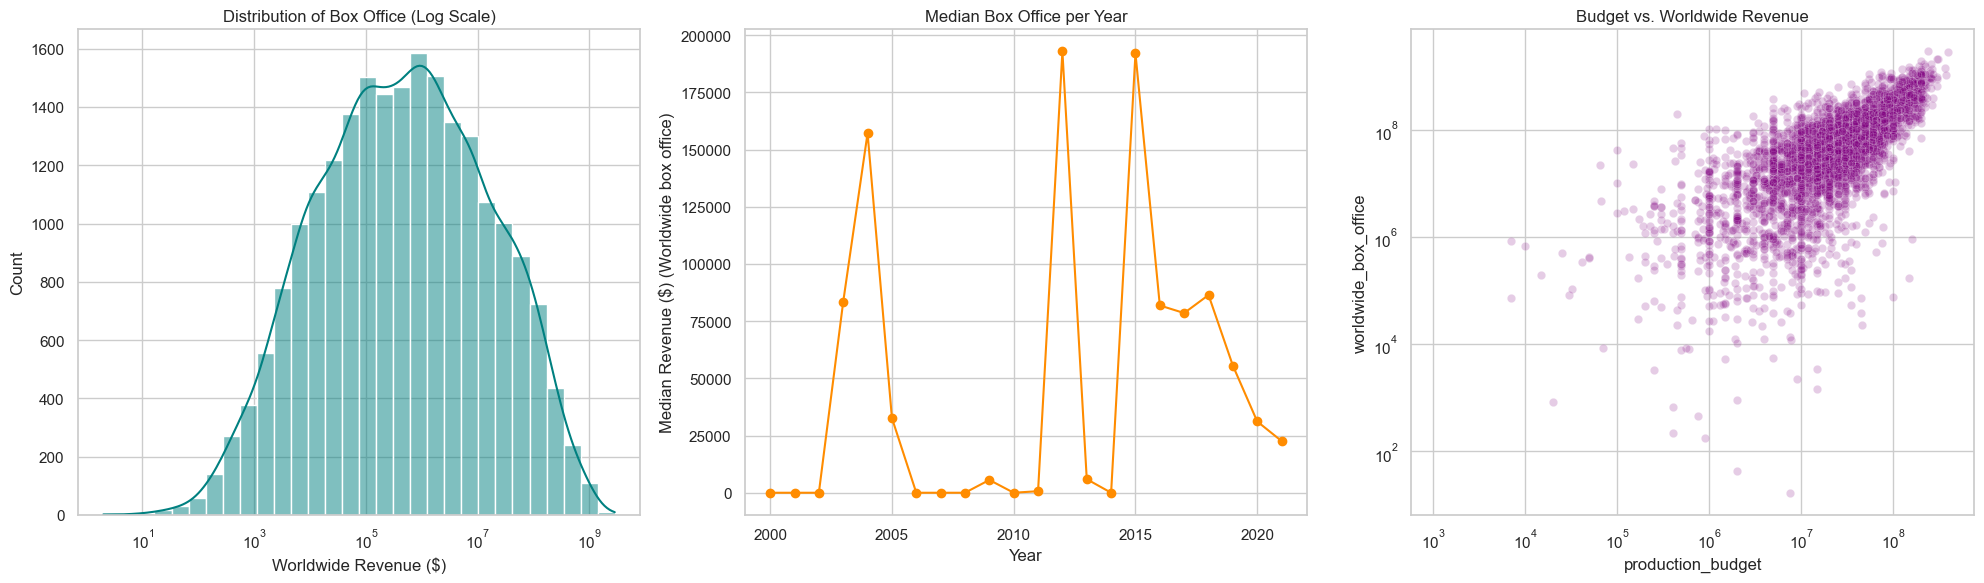

In [46]:
# Set the style for a professional look. Code by Muayyad 
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots in 1 row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Distribution of Worldwide Box Office (Log Scale)
# This shows us the scale of the movies—most are small, few are blockbusters.
sns.histplot(df_sales[df_sales['worldwide_box_office'] > 0]['worldwide_box_office'], 
             bins=30, kde=True, ax=axes[0], log_scale=True, color='teal')
axes[0].set_title('Distribution of Box Office (Log Scale)')
axes[0].set_xlabel('Worldwide Revenue ($)')

# 2. Box Office Trends Over Time
# Shows how the industry has grown from the 30k records.
yearly_revenue = df_sales.groupby('year')['worldwide_box_office'].median()
axes[1].plot(yearly_revenue.index, yearly_revenue.values, marker='o', color='darkorange')
axes[1].set_title('Median Box Office per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Revenue ($) (Worldwide box office)')

# 3. Production Budget vs. Worldwide Box Office
# A scatter plot to see the correlation between spending and earning.
sns.scatterplot(data=df_sales[df_sales['production_budget'] > 0], 
                x='production_budget', y='worldwide_box_office', 
                alpha=0.2, ax=axes[2], color='purple')
axes[2].set_title('Budget vs. Worldwide Revenue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

1. The first graph shows that the market is dominated by a few successful movies (Blockbusters).
2. In the second graph we used the median to eleminate the effect of outliers, the decline around the year 2020 is consistent with the global impact of covid pandemic. (we'll investigate or drop the 0 values going further)
3. The last chart shows that there is a correlation between budget and world wide box office, but there is also a big variation, meaning that we need to look at other factors like "reviews" and "genres" to predict a blockbuster with our AI models.


C:\Users\BiggiE\AppData\Local\Temp\ipykernel_2024\770009325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
C:\Users\BiggiE\AppData\Local\Temp\ipykernel_2024\770009325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')


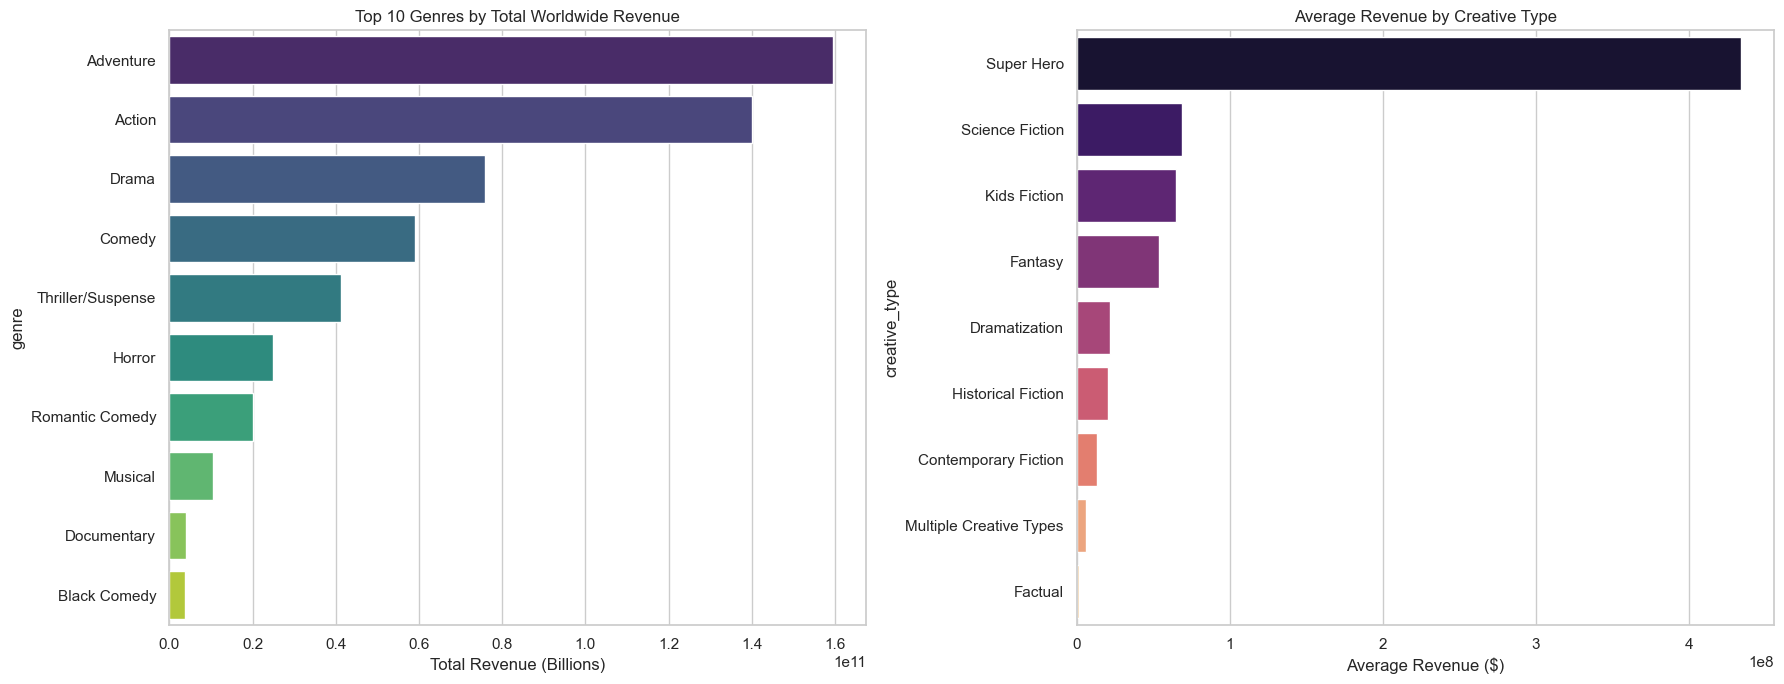

In [47]:
# Creating a figure with 2 subplots side-by-side for the two features that we see important. Code by Muayyad 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 Genres by total revenue
top_genres = df_sales.groupby('genre')['worldwide_box_office'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genres by Total Worldwide Revenue')
axes[0].set_xlabel('Total Revenue (Billions)')

# Average revenue by creative type
creative_type = df_sales.groupby('creative_type')['worldwide_box_office'].mean().sort_values(ascending=False)
sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')
axes[1].set_title('Average Revenue by Creative Type')
axes[1].set_xlabel('Average Revenue ($)')

plt.tight_layout()
plt.show()

The categorical analysis reveals that Adventure and Action genres lead in total market volume, while the Super Hero creative type is the strongest individual indicator of high average revenue. These two key features will be very useful to detect blockbusters in the AI model.


Creating a master table that has all the required features to be used for AI modeling in a way that answers the business question:

In [48]:
# Data cleaning, and reviews aggregation, this will be used to add new features when making a master table. Code by Muayyad 

# Changing data types to numbers for some numerical columns in user and expert reviews dataframes:
df_user['idvscore'] = pd.to_numeric(df_user['idvscore'], errors='coerce')
df_expert['idvscore'] = pd.to_numeric(df_expert['idvscore'], errors='coerce')
df_user['thumbsUp'] = pd.to_numeric(df_user['thumbsUp'], errors='coerce')
df_user['thumbsTot'] = pd.to_numeric(df_user['thumbsTot'], errors='coerce')

# Aggregate one row per URL for user reviews:
user_agg = df_user.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count','thumbsUp': 'sum','thumbsTot': 'sum'}).reset_index()
user_agg.columns = ['url', 'user_idvscore_avg', 'user_rev_count','user_thumbsUp_tot', 'user_thumbsTot_tot']

# Create the Thumbs Down column using formula: thumbstot-thumbsup and dropping thumbs total (we keep only negative and positive)
user_agg['user_thumbsDown_tot'] = user_agg['user_thumbsTot_tot'] - user_agg['user_thumbsUp_tot']
user_agg = user_agg.drop(columns=['user_thumbsTot_tot'])

# Aggregate one row per URL for expert reviews:
expert_agg = df_expert.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count'}).reset_index()
expert_agg.columns = ['url', 'expert_score_avg', 'expert_rev_count']


In [49]:
# Creating the master table. Code by Muayyad 

# Standardize titles for the merge
df_sales['title_clean'] = df_sales['title'].str.lower().str.strip()
df_meta['title_clean'] = df_meta['title'].str.lower().str.strip()

# Merge Meta and Sales
df_master = pd.merge(
    df_meta, 
    df_sales, 
    on=['title_clean', 'year'], 
    how='inner', 
    suffixes=('', '_sales')
)

# Join the aggregated reviews tables
df_master = pd.merge(df_master, user_agg, on='url', how='left')
df_master = pd.merge(df_master, expert_agg, on='url', how='left')

# Create unique Movie ID
df_master['movie_id'] = range(1, len(df_master) + 1)

# Handle missing review data by filling NaNs with 0 (this is useful for the AI model)
review_cols = [
    'user_idvscore_avg', 'user_rev_count', 'user_thumbsUp_tot', 
    'user_thumbsDown_tot', 'expert_score_avg', 'expert_rev_count'
]
df_master[review_cols] = df_master[review_cols].fillna(0)

# Final cleanup of duplicated columns
if 'title_sales' in df_master.columns:
    df_master.drop(columns=['title_sales'], inplace=True)

print(f"New Master Table created with {len(df_master)} movies.")
df_master[['title', 'year', 'user_thumbsUp_tot', 'user_thumbsDown_tot', 'worldwide_box_office']].head()

New Master Table created with 8025 movies.


,title,year,user_thumbsUp_tot,user_thumbsDown_tot,worldwide_box_office
0,10 Cloverfield Lane,2016,390.0,535.0,108286422.0
1,10 Years,2012,1.0,1.0,987640.0
2,100 Bloody Acres,2013,0.0,0.0,0.0
3,"10,000 km",2015,0.0,0.0,20452.0
4,1001 Grams,2015,0.0,0.0,47019.0


In [50]:
# I want to add the movie ID back to the original dataframes as foreign key for better data integrity. Code by Muayyad 
# Create mapping with year and title
id_mapping = df_master[['title_clean', 'year', 'movie_id']].drop_duplicates()

# Add movie_id to df_sales
df_sales = pd.merge(df_sales, id_mapping, on=['title_clean', 'year'], how='left')

# Add movie_id to df_meta
df_meta = pd.merge(df_meta, id_mapping, on=['title_clean', 'year'], how='left')

# Add movie_id to the reviews datasets (using the 'url' which is unique)
# Create mapping with URL
url_mapping = df_master[['url', 'movie_id']].drop_duplicates()

df_user = pd.merge(df_user, url_mapping, on='url', how='left')
df_expert = pd.merge(df_expert, url_mapping, on='url', how='left')

df_sales.head(3) # check


,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url,title_clean,movie_id
0,2000,January,Bakha Satang,Drama,76576.0,0.0,76576.0,0.0,0.0,0.0,0.0,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...,bakha satang,NaN
1,2001,January,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,5486209.0,2433.0,3.1,0.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust,antitrust,531.0
2,2000,January,Santitos,NaN,0.0,378562.0,0.0,0.0,0.0,0.0,0.0,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos,santitos,5044.0


EDA and feature engineering for the master table:

In [51]:
# check data types and missing data. Code by Muayyad 
pd.concat([df_master.dtypes, df_master.isna().sum()], axis=1, keys=['Data Type', 'Missing data count'])

,Data Type,Missing data count
url,object,0
title,object,0
studio,object,197
rating,object,0
runtime,float64,0
cast,object,0
director,object,0
genre,object,8
summary,object,0
awards,object,4802


In [52]:
# Convert text columns we need to categorical.. Code by Muayyad 
df_master['rating'] = df_master['rating'].astype('category')
df_master['release_date'] = df_master['release_date'].astype('category') # because previously we only kept the year in this column
df_master['genre'] = df_master['genre'].astype('category')
df_master['studio'] = df_master['studio'].astype('category')
df_master['creative_type'] = df_master['creative_type'].astype('category')

# Convert floats to integers for columns that are "counts"
# better for the financial columns too since we have no decimal places
cols_to_int = ['production_budget', 'worldwide_box_office', 'theatre_count', 
               'user_thumbsUp_tot', 'user_thumbsDown_tot', 'metascore']

df_master[cols_to_int] = df_master[cols_to_int].astype('int64')

df_master.dtypes # check

url                                 object
title                               object
studio                            category
rating                            category
runtime                            float64
cast                                object
director                            object
genre                             category
summary                             object
awards                              object
metascore                            int64
userscore                          float64
RelDate                     datetime64[ns]
title_clean                         object
year                                 int32
release_date                      category
genre_sales                         object
international_box_office           float64
domestic_box_office                float64
worldwide_box_office                 int64
production_budget                    int64
opening_weekend                    float64
theatre_count                        int64
avg run per

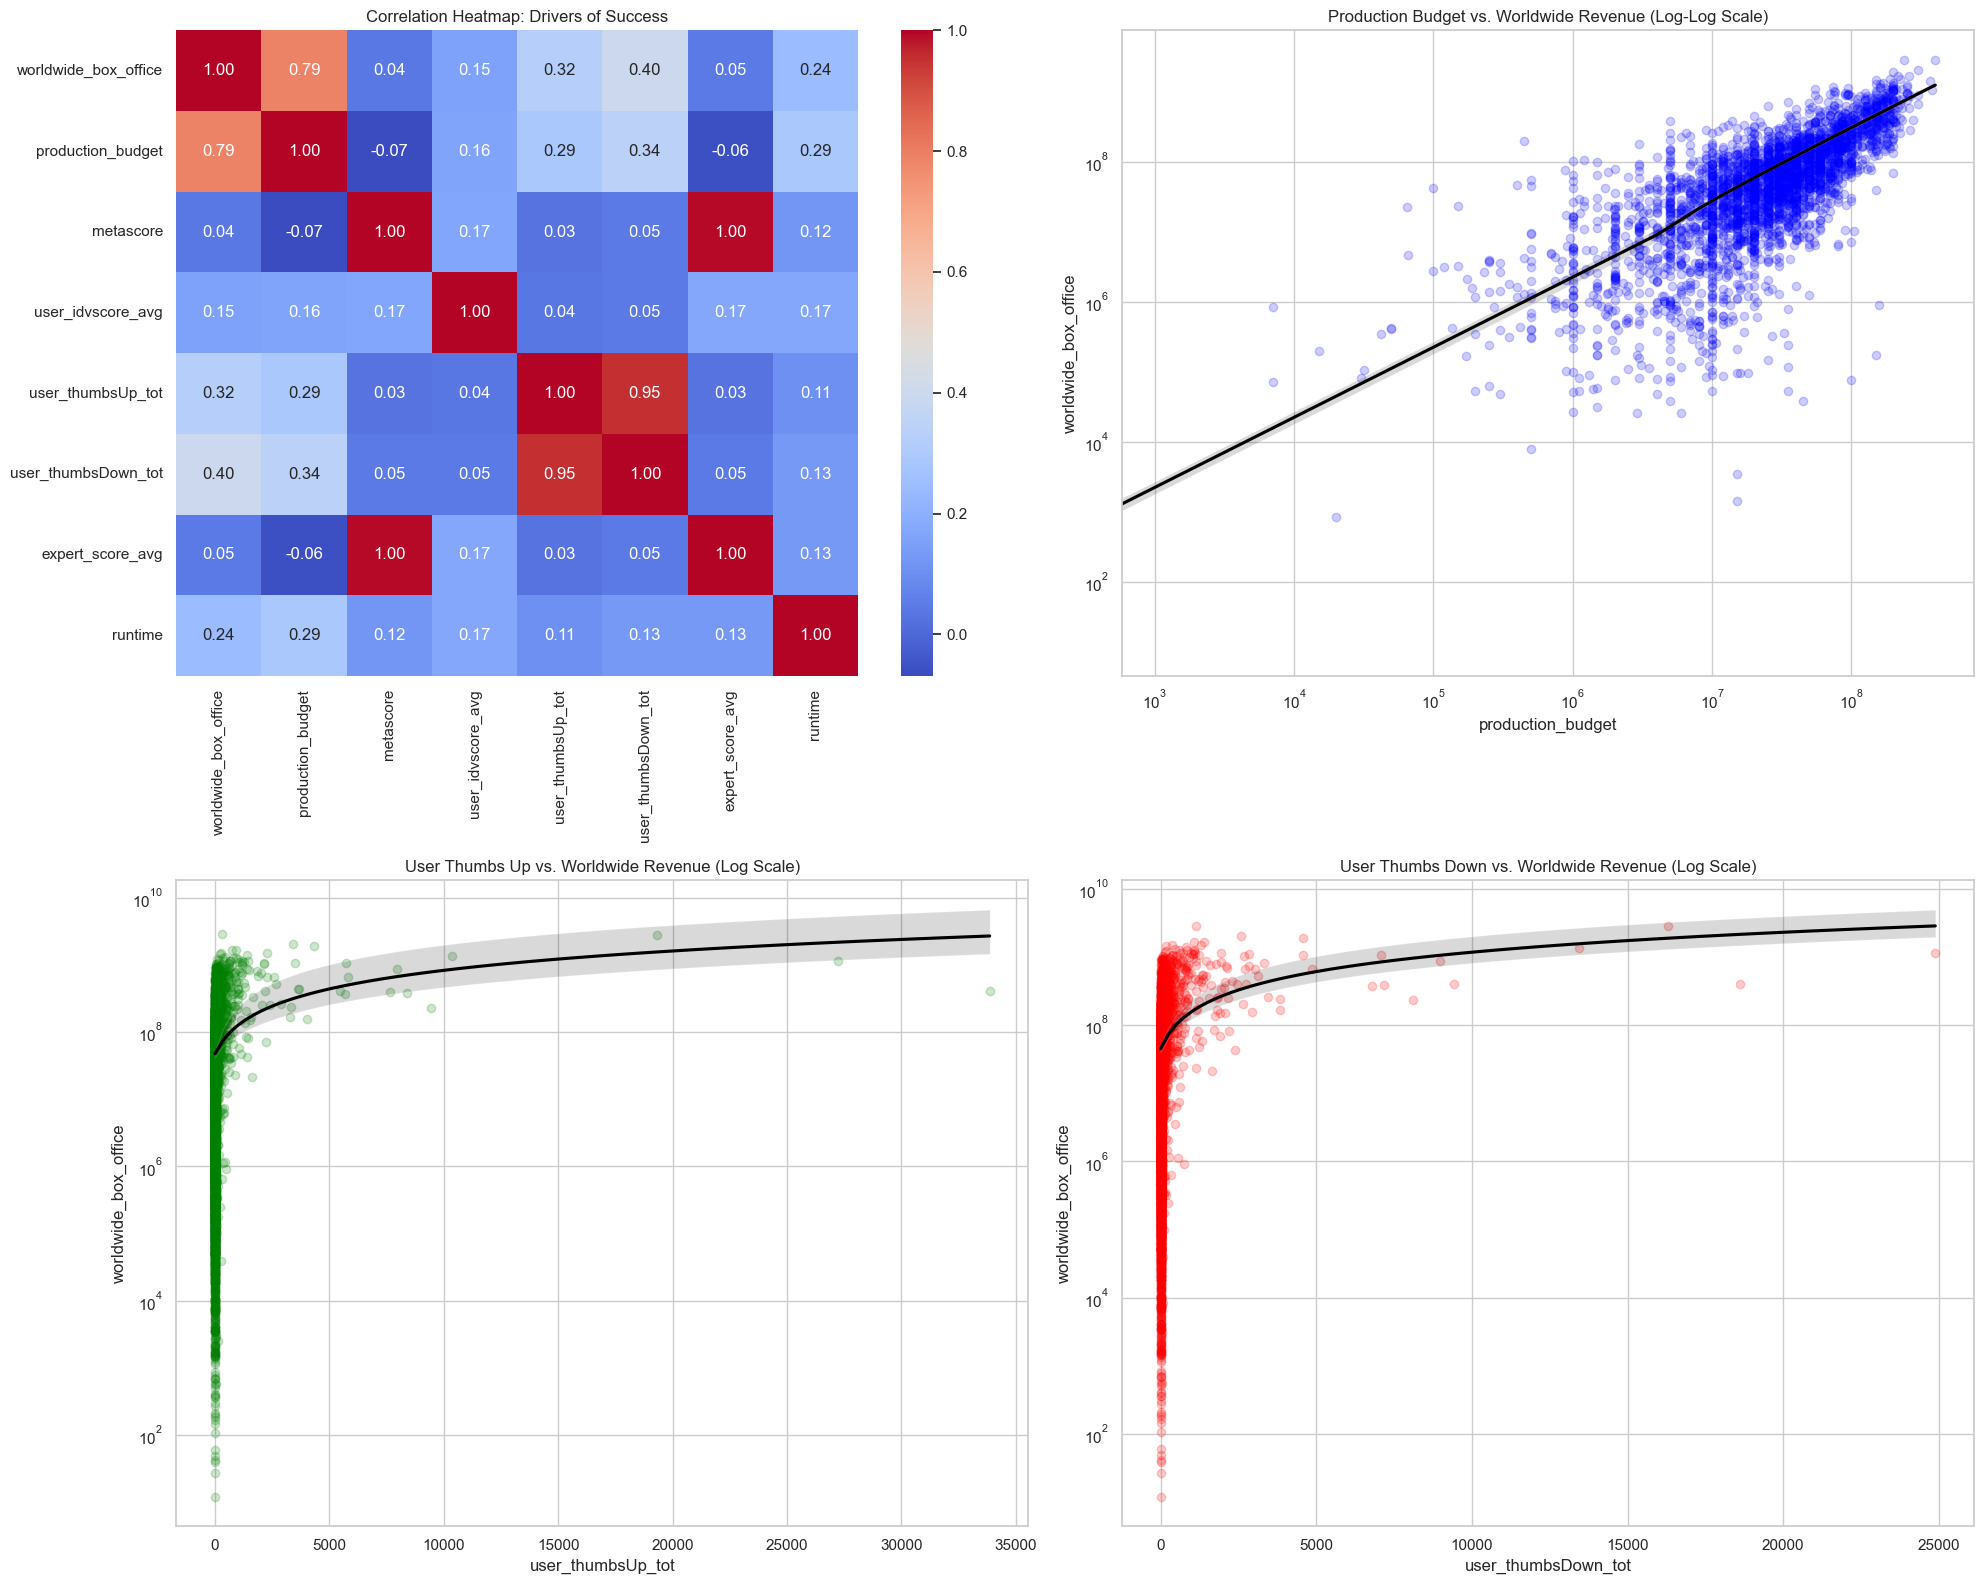

In [53]:
# Set up a 2x2 grid for a nicer visualization. Code by Muayyad 
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Top-Left: Correlation Heatmap
cols_to_corr = [
    'worldwide_box_office', 'production_budget', 'metascore', 
    'user_idvscore_avg', 'user_thumbsUp_tot', 'user_thumbsDown_tot', 
    'expert_score_avg', 'runtime'
]
sns.heatmap(df_master[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0,0])
axes[0,0].set_title('Correlation Heatmap: Drivers of Success')

# Top-Right: Budget vs Revenue (Strongest Correlation: 0.79)
sns.regplot(data=df_master, x='production_budget', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'blue'}, line_kws={'color':'black'}, ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
axes[0,1].set_title('Production Budget vs. Worldwide Revenue (Log-Log Scale)')

# Bottom-Left: Thumbs Up vs Revenue
sns.regplot(data=df_master, x='user_thumbsUp_tot', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'green'}, line_kws={'color':'black'}, ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].set_title('User Thumbs Up vs. Worldwide Revenue (Log Scale)')

# Bottom-Right: Thumbs Down vs Revenue
sns.regplot(data=df_master, x='user_thumbsDown_tot', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'red'}, line_kws={'color':'black'}, ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_title('User Thumbs Down vs. Worldwide Revenue (Log Scale)')

plt.tight_layout()
plt.savefig('eda_master_grid.png')

The correlation heatmap shows that spending money on the budget is the most reliable way to predict how much money a movie will make.
Production budget has the most correlation with the world-wide-revenue.
Thumbs-up and Thumbs-down both represent engagement/audience reach, that means most successful movies get alot of hate, or love!

Since we won't use all the features for our AI models, we'll create a final dataset and we'll keep only the features that we see useful, we'll also keep only Worldwide box office as our "Y" where the value is more than "0" to train our AI model, we'll also discard international and domestic box office as we won't use those to prevent data leakage.

We'll keep the records of the unknown world wide box office for later so we can use our developed model to predict it, we'll remove them from the training data when we finish feature engineering.

In [54]:
# Define the columns we want to keep. Code by Muayyad 
features_to_keep = [
    'worldwide_box_office', 'production_budget', 'theatre_count', 
    'runtime', 'metascore', 'userscore', 'expert_score_avg',
    'user_thumbsUp_tot', 'user_thumbsDown_tot', 'user_rev_count', 
    'rating', 'genre', 'release_date', 'year', 'creative_type', 'movie_id'
]

# Create the final modeling dataframe
df_final = df_master[features_to_keep].copy()

df_final.tail(5)

,worldwide_box_office,production_budget,theatre_count,runtime,metascore,userscore,expert_score_avg,user_thumbsUp_tot,user_thumbsDown_tot,user_rev_count,rating,genre,release_date,year,creative_type,movie_id
8020,55348693,50000000,3394,102.0,34,4.1,40.261905,71,54,54,PG-13,Comedy,February,2016,Contemporary Fiction,8021
8021,12506188,35000000,2501,83.0,26,4.4,30.428571,10,12,21,PG,"Action,Adventure,Sci-Fi,Family",August,2006,Super Hero,8022
8022,2784,0,0,96.0,55,5.7,56.875000,1,0,3,Not Rated,"Drama,Comedy,Animation",September,2016,Contemporary Fiction,8023
8023,1004629935,150000000,3827,108.0,78,8.6,78.093023,1186,740,276,PG,"Action,Adventure,Comedy,Crime,Animation,Family",March,2016,Kids Fiction,8024
8024,0,0,2,106.0,50,7.2,53.555556,0,0,1,Unrated,"Fantasy,Comedy,Romance",February,2003,NaN,8025


In [55]:
# check file types and missing data for our final table. Code by Muayyad 
pd.concat([df_final.dtypes, df_final.isna().sum()], axis=1, keys=['Data Type', 'Missing data count'])

# check length of the dataframe (how many records)
# print('original length of dataframe:', len(df_final)) # code inspired by Linear-Logistic-Regression code

,Data Type,Missing data count
worldwide_box_office,int64,0
production_budget,int64,0
theatre_count,int64,0
runtime,float64,0
metascore,int64,0
userscore,float64,0
expert_score_avg,float64,0
user_thumbsUp_tot,int64,0
user_thumbsDown_tot,int64,0
user_rev_count,int64,0


Worldwide_box_office will be our target (Y) and the others are our features (X).
We'll make some more feature engineering below:

In [56]:
# checking how many times each genre appears in the dataset, split the coma seperated genres (extracted initially from meta table). Code by Muayyad 
df1 = df_final['genre_list'] = df_final['genre'].str.split(',')
df1 = df_final.explode('genre_list') # to put seperated genres in columns

In [57]:
# Group genres to see the most frequent ones
df1.groupby('genre_list')['genre_list'].count().sort_values(ascending=False)

genre_list
Drama          4283
Comedy         2504
Thriller       1944
Documentary    1371
Romance        1277
Action         1086
Crime           972
Adventure       836
Horror          723
Mystery         630
Biography       608
Fantasy         547
Sci-Fi          532
Family          528
Music           418
History         372
Animation       277
War             270
Sport           233
Musical         128
Western          76
News             52
Short             8
Adult             7
Name: genre_list, dtype: int64

In [58]:
# We'll select the first 10 genres, because from our initial EDA we know that Adventure is the most successful genre, so it is important for the prediction. Code by Muayyad 
# Prepare the list and the Top 10 Target Genres
df_final['genre_list'] = df_final['genre'].astype(str).str.split(',')
main_genres = [
    'Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 
    'Documentary', 'Adventure', 'Horror', 'Crime', 'Sci-Fi'
]

# this piece of code was enhanced with AI instead of the very long logic we used
for g in main_genres:
    # Clean the genre name for the column header (remove spaces/dashes)
    col_name = f'is_{g.lower().replace(" ", "_").replace("-", "_")}'
    
    # Check if the genre exists in the list for each row
    # .apply handles the list check; .astype(int) turns True/False into 1/0
    df_final[col_name] = df_final['genre_list'].apply(lambda x: g in [i.strip() for i in x]).astype('int64')

# Add "is_other_genre" (count of genres NOT in our top 10)
df_final['is_other_genre'] = df_final['genre_list'].apply(
    lambda x: len([i.strip() for i in x if i.strip() not in main_genres])
).astype('int64')

# Add "nr_genres" (total count of genres for that movie)
df_final['nr_genres'] = df_final['genre_list'].apply(lambda x: len(x)).astype('int64')

# Drop the temporary list column and the genre (the source column after encoding) to keep df_final clean
df_final = df_final.drop(columns=['genre_list','genre'])

print("Top 10 Genre features created successfully!")
print(df_final.filter(like='is_').head())

Top 10 Genre features created successfully!
   is_drama  is_comedy  is_thriller  is_action  is_romance  is_documentary  \
0         1          0            1          1           0               0   
1         1          1            0          0           1               0   
2         0          1            0          0           0               0   
3         1          1            0          0           1               0   
4         1          0            0          0           0               0   

   is_adventure  is_horror  is_crime  is_sci_fi  is_other_genre  
0             0          1         0          1               1  
1             0          0         0          0               0  
2             0          1         0          0               0  
3             0          0         0          0               0  
4             0          0         0          0               0  


In [59]:
# Create season map to create a new feature for the season.. Code by Muayyad 
season_map = {
    'January': 'Winter', 'February': 'Winter', 'December': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}

# Map the seasons into df_final 
# (We use .str.strip() just in case there are hidden spaces in the month names)
df_final['season'] = df_final['release_date'].str.strip().map(season_map)

# One-Hot Encode the seasons (Convert to is_summer, is_winter, etc.)
season_dummies = pd.get_dummies(df_final['season'], prefix='is_season').astype('int64')

# Join the new columns and drop the original text 'season' and 'release_date'
df_final = pd.concat([df_final, season_dummies], axis=1)
df_final = df_final.drop(columns=['season', 'release_date'])

print(df_final.filter(like='is_season').head())

   is_season_Autumn  is_season_Spring  is_season_Summer  is_season_Winter
0                 0                 1                 0                 0
1                 1                 0                 0                 0
2                 0                 0                 1                 0
3                 0                 0                 1                 0
4                 0                 1                 0                 0


In [60]:
df_final.head(5)

,worldwide_box_office,production_budget,theatre_count,runtime,metascore,userscore,expert_score_avg,user_thumbsUp_tot,user_thumbsDown_tot,user_rev_count,...,is_adventure,is_horror,is_crime,is_sci_fi,is_other_genre,nr_genres,is_season_Autumn,is_season_Spring,is_season_Summer,is_season_Winter
0,108286422,15000000,3391,104.0,76,7.7,75.744186,390,535,201,...,0,1,0,1,1,6,0,1,0,0
1,987640,0,3,100.0,61,6.9,62.666667,1,1,7,...,0,0,0,0,0,3,1,0,0,0
2,0,0,13,91.0,63,7.5,65.800000,0,0,2,...,0,1,0,0,0,2,0,0,1,0
3,20452,0,0,99.0,75,7.4,75.166667,0,0,2,...,0,0,0,0,0,3,0,0,1,0
4,47019,0,0,93.0,65,0.0,67.000000,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [61]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8025 entries, 0 to 8024
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   worldwide_box_office  8025 non-null   int64   
 1   production_budget     8025 non-null   int64   
 2   theatre_count         8025 non-null   int64   
 3   runtime               8025 non-null   float64 
 4   metascore             8025 non-null   int64   
 5   userscore             8025 non-null   float64 
 6   expert_score_avg      8025 non-null   float64 
 7   user_thumbsUp_tot     8025 non-null   int64   
 8   user_thumbsDown_tot   8025 non-null   int64   
 9   user_rev_count        8025 non-null   int64   
 10  rating                8025 non-null   category
 11  year                  8025 non-null   int32   
 12  creative_type         7369 non-null   category
 13  movie_id              8025 non-null   int64   
 14  is_drama              8025 non-null   int64   
 15  is_c

In [62]:
# check Nan values vs "0" in Runtime to impute
nan_count = df_final['runtime'].isna().sum()
zero_count = (df_final['runtime'] == 0).sum()

print(f"Number of Nan values: {nan_count}")
print(f"Number of 0.0 runtimes: {zero_count}")

Number of Nan values: 0
Number of 0.0 runtimes: 164


In [63]:


# Flag the rows that are missing runtime so we can look at them later. Code by Muayyad 
missing_mask = (df_final['runtime'] == 0) | (df_final['runtime'].isna())

# Convert the 0.0 values to NaN for the imputer
df_final['runtime'] = df_final['runtime'].replace(0, np.nan)

# Select columns to take into consideration # code enhanced with AI instead of the manual naming of the previously encoded columns
impute_cols = ['runtime', 'production_budget'] + [col for col in df_final.columns if 'is_' in col]

# Initialize and run the Imputer, we'll check the nearest 3 neighbours
imputer = KNNImputer(n_neighbors=3)
df_temp = pd.DataFrame(imputer.fit_transform(df_final[impute_cols]), columns=impute_cols)

# We create a small table showing the "Before" (which was 0/NaN) and the "After"
verification_df = pd.DataFrame({
    'Old_Runtime': 0, # this was changed to 0 earlier when we were changing data types
    'Imputed_Runtime': df_temp.loc[missing_mask, 'runtime'].values
})

print("Check the imputation")
print(verification_df.head(10)) 
# This lets you see if the numbers look realistic (for example, 90, 105, 120)




Check the imputation
   Old_Runtime  Imputed_Runtime
0            0        93.000000
1            0        82.000000
2            0        87.333333
3            0       108.000000
4            0       116.666667
5            0       116.000000
6            0       101.333333
7            0        85.000000
8            0       108.000000
9            0        91.000000


In [64]:
# The numbers actually look realistic. Code by Muayyad 
# Put the verified runtimes back into df_final
df_final['runtime'] = df_temp['runtime'].values

# Final cleanup: round to whole minutes
df_final['runtime'] = df_final['runtime'].round(0).astype('int64')

del df_temp

print("Final check number of zeros =", (df_final['runtime'] == 0).sum())

Final check number of zeros = 0


# Preparing for modelling

we'll create a new table called df_final_clean that has values greater than 0 for world wide box office, and move the ones that has 0 values to another dataframe to predict them later

In [77]:
# Now, I want to remove the movies that have 0 world wide box office and move them to another table. Code by Muayyad 
# Create a table with only movies that have a box office greater than 0
df_final_clean = df_final[df_final['worldwide_box_office'] > 0].copy()

# Move the rows with 0 box office to a separate "Zero Box Office" table
df_zero_box_office = df_final[df_final['worldwide_box_office'] == 0].copy()

# Verification
print(f"Movies with valid Box Office data: {df_final_clean.shape[0]}")
print(f"Movies moved to the Zero Table: {df_zero_box_office.shape[0]}")

# Check the minimum value in our new clean table to be sure
print(f"New minimum Box Office: ${df_final_clean['worldwide_box_office'].min()}")

Movies with valid Box Office data: 5081
Movies moved to the Zero Table: 2944
New minimum Box Office: $12


### Outlier Analysis ---- Ahmed
To better understand extreme values in key numerical variables, boxplots are used to identify potential outliers in movie runtime, production budget, and box office performance. These variables are known to be right-skewed in real-world movie datasets and may require transformation to ensure better modeling.


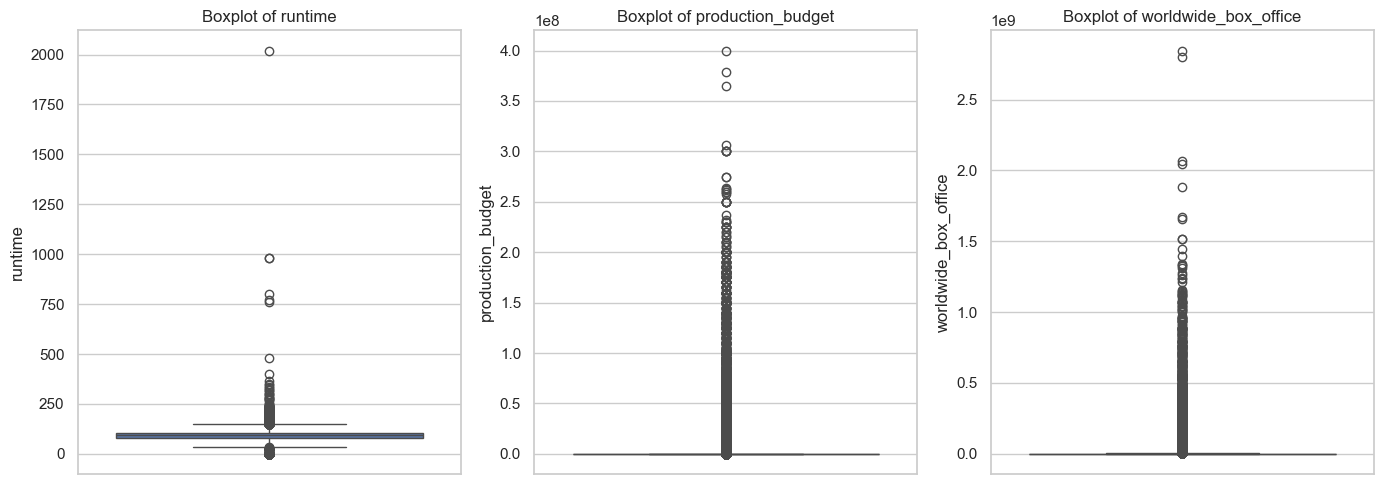

In [78]:
#  Visualize outliers using boxplots ------ Ahmed
#numeric_cols = ['runtime', 'production_budget', 'worldwide_box_office']    
numeric_cols = ['runtime', 'production_budget', 'worldwide_box_office'] # specify the numerical columns to analyze

plt.figure(figsize=(14, 5))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_sales[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()
# Observations:
# Runtime:few movies have extremely long runtimes, which could skew analyses
# production_budget:several movies with very high budgets, indicating potential outliers
# worldwide_box_office:few movies with exceptionally high box office earnings
# -----These outliers need to be addressed before modeling-----    

The boxplots:
reveal extreme values, particularly for budget and box office revenue. These represent blockbuster movies rather than data errors. Removing them would eliminate meaningful observations, therefore a logarithmic transformation is applied to reduce skewness while preserving relative differences.


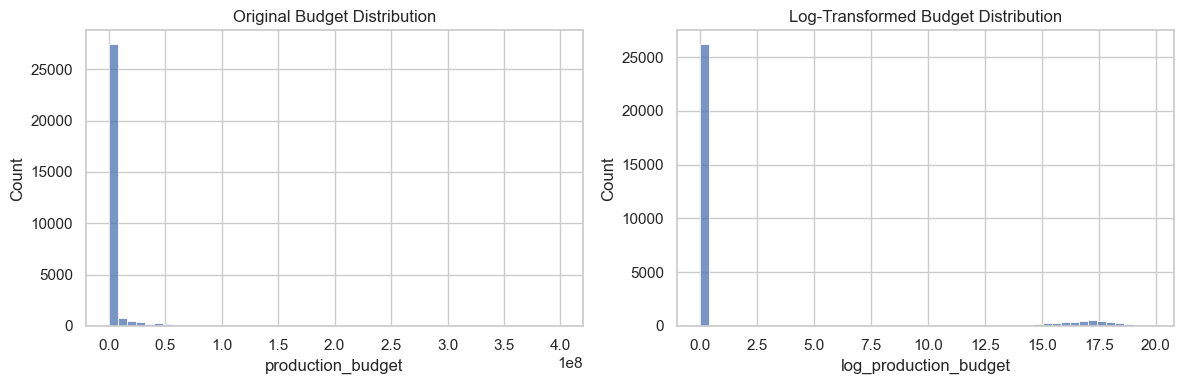

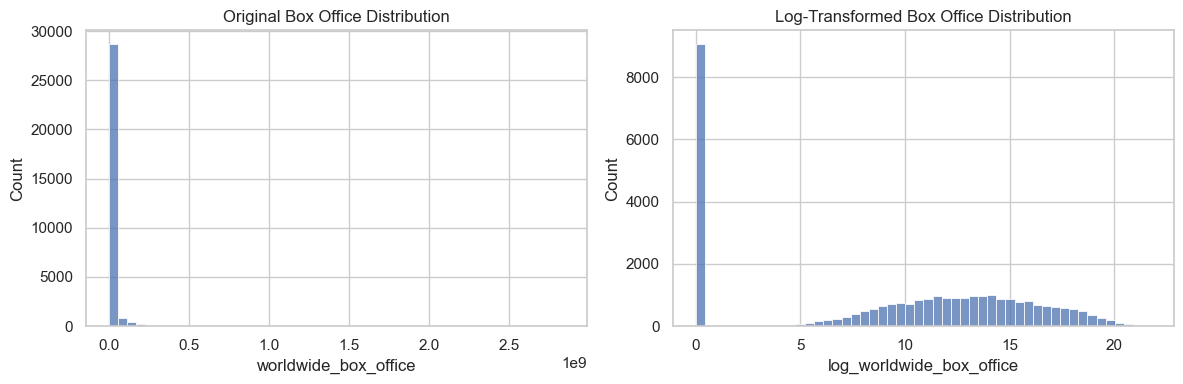

In [79]:
# Log transformation applied to reduce skewness identified during EDA ------ Ahmed 

df_sales['log_production_budget'] = np.log1p(df_sales['production_budget'])
df_sales['log_worldwide_box_office'] = np.log1p(df_sales['worldwide_box_office'])

# Visualize the transformed distributions
# Visualizing the effect of log transformation on budget
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_sales['production_budget'], bins=50)
plt.title('Original Budget Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_sales['log_production_budget'], bins=50)
plt.title('Log-Transformed Budget Distribution')

plt.tight_layout()
plt.show()
# Visualizing the effect of log transformation on box office
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_sales['worldwide_box_office'], bins=50)
plt.title('Original Box Office Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_sales['log_worldwide_box_office'], bins=50)
plt.title('Log-Transformed Box Office Distribution')

plt.tight_layout()
plt.show()

### Target Variable Transformation (Worldwide Box Office)

Due to the highly skewed distribution of movie revenues, the prediction task is formulated as a classification problem by discretizing worldwide box office performance into quartile-based success categories.

The worldwide box office revenue exhibits a highly right-skewed distribution, with a small number of blockbuster movies generating disproportionately large revenues compared to the majority of films. Directly predicting continuous revenue values in such a setting can lead to unstable regression models that are overly influenced by extreme outliers.

To address this issue while preserving the economic importance of blockbuster movies, the prediction task is reformulated as a classification problem. Worldwide box office revenue is discretized into four performance categories. Movies in the top 10% of revenue are assigned to a dedicated “Blockbuster” class, ensuring that extreme but meaningful outcomes are not removed or diluted. The remaining 90% of movies are divided into three equally sized groups (Low, Medium, and High) using quantile-based bucketing to maintain class balance.

This approach reduces variance, improves model stability, and aligns predictions with business-relevant success tiers, while retaining the full spectrum of revenue outcomes in the dataset.


Blockbuster threshold (top 10%): 217,194,805


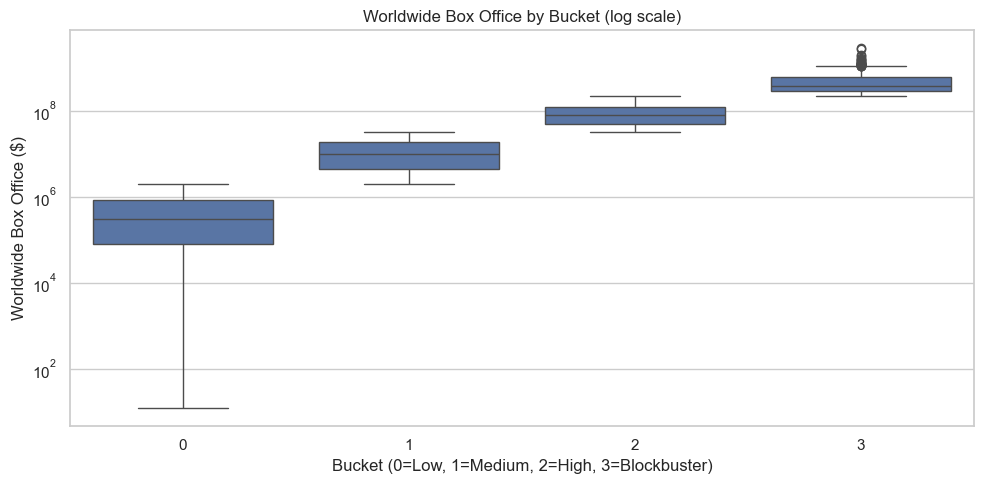

,worldwide_box_office,y_bucket,y_class
0,108286422,2,High
1,987640,0,Low
3,20452,0,Low
4,47019,0,Low
6,143782,0,Low
7,4581361,1,Medium
9,3712409,1,Medium
10,17306648,1,Medium
11,71118378,2,High
12,180765061,2,High


In [ ]:
#Stage 1: managing the predicted variable Y ---------------------------------Ahmed



# 0. blockbuster threshold 
y_raw = df_final_clean['worldwide_box_office']

blockbuster_threshold = y_raw.quantile(0.90)
print(f"Blockbuster threshold (top 10%): {blockbuster_threshold:,.0f}")

# Create y_bucket as a nullable integer column (no dtype issues)
df_final_clean['y_bucket'] = pd.Series(pd.NA, index=df_final_clean.index, dtype="Int64")

# 1. Assign blockbuster class
df_final_clean.loc[
    df_final_clean['worldwide_box_office'] >= blockbuster_threshold,
    'y_bucket'
] = 3

# 2. Bucket the remaining 90% into 3 balanced classes
mask_non_blockbuster = df_final_clean['y_bucket'].isna()

q = pd.qcut(
    df_final_clean.loc[mask_non_blockbuster, 'worldwide_box_office'],
    q=3,
    duplicates='drop'   # safe even without zeros
)

# Convert qcut bins to integer codes 0,1,2 and assign
df_final_clean.loc[mask_non_blockbuster, 'y_bucket'] = q.cat.codes.astype("Int64")

# 3. Final type as regular int & print buckets(optional)
df_final_clean['y_bucket'] = df_final_clean['y_bucket'].astype(int)
df_final_clean['y_bucket'].value_counts().sort_index()

#4. Visualize the buckets

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_final_clean, x='y_bucket', y='worldwide_box_office')
plt.yscale('log')  # revenue is skewed, log scale makes it readable
plt.title('Worldwide Box Office by Bucket (log scale)')
plt.xlabel('Bucket (0=Low, 1=Medium, 2=High, 3=Blockbuster)')
plt.ylabel('Worldwide Box Office ($)')
plt.tight_layout()
plt.show()

#4. Create a classification column for each movie (row) 
bucket_map = {
    0: 'Low',
    1: 'Medium',
    2: 'High',
    3: 'Blockbuster'
}

df_final_clean['y_class'] = df_final_clean['y_bucket'].map(bucket_map)
#Verification by prinitng few rows
df_final_clean[['worldwide_box_office', 'y_bucket', 'y_class']].head(10)

#5. Fix the predicted variable y for modeling ------ Ahmed
y = df_final_clean['y_bucket']



Since the prediction task is formulated as a classification problem, the target variable is represented as discrete classes rather than continuous values. Therefore, scaling or normalization is applied only to predictor variables. No transformations are applied to the target labels.


Missing value percentage (%):
production_budget    0.0
runtime              0.0
dtype: float64


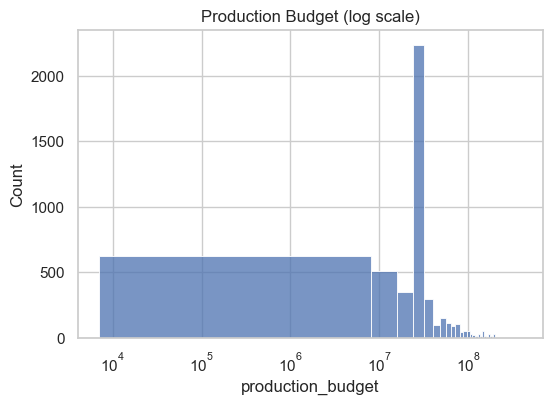

Number of zero budgets: 0
Zeros: 0
NaNs: 0
Total rows: 5081
99th percentile runtime cap: 159.19999999999982


,runtime,runtime_scaled,production_budget,log_budget,log_budget_scaled
count,5081.000000,5.081000e+03,5.081000e+03,5081.000000,5.081000e+03
mean,105.652824,6.607586e-16,3.661072e+07,16.951329,9.733079e-16
std,19.883656,1.000098e+00,4.003113e+07,1.104002,1.000098e+00
min,21.000000,-5.132893e+00,7.000000e+03,8.853808,-7.335417e+00
25%,94.000000,-6.905789e-01,2.000000e+07,16.811243,-1.269023e-01
50%,103.000000,-1.428964e-01,2.510000e+07,17.038378,7.885628e-02
75%,115.000000,5.873470e-01,3.500000e+07,17.370859,3.800449e-01
max,808.000000,3.277077e+00,4.000000e+08,19.806975,2.586884e+00


In [111]:
# Stage 2: managing some features (Production Budget & Runtime)-----------------Ahmed


#Checks of scale and value for budget and runtime ----------------------------------------------------------

cols_to_check = ['production_budget', 'runtime'] # runtime is already imputed

missing_stats = (
    df_final_clean[cols_to_check]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

print("Missing value percentage (%):")
print(missing_stats)

# Scale of production budget
df_final_clean[cols_to_check].describe()

plt.figure(figsize=(6,4))
sns.histplot(df_final_clean['production_budget'], bins=50)
plt.xscale('log')
plt.title('Production Budget (log scale)')
plt.show()


from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# scaling budget & log transform (Production Budget)--------------------------------------------------------Ahmed

# Check for any missing budgets
num_zeros = (df_final_clean['production_budget'] == 0).sum()
print(f"Number of zero budgets: {num_zeros}")
print("Zeros:", (df_final_clean['production_budget'] == 0).sum())
print("NaNs:", df_final_clean['production_budget'].isna().sum())
print("Total rows:", len(df_final_clean))

# Create missing indicator
df_final_clean['budget_missing'] = (df_final_clean['production_budget'] == 0).astype(int)
import numpy as np

# Replace zeros with NaN
df_final_clean['production_budget'] = df_final_clean['production_budget'].replace(0, np.nan)

# Log-transform (budget is highly skewed)
df_final_clean['log_budget'] = np.log1p(df_final_clean['production_budget'])

# Median imputation on log scale
imp = SimpleImputer(strategy='median')
df_final_clean[['log_budget']] = imp.fit_transform(df_final_clean[['log_budget']])

# Scale the imnputed log transformed production budget
scaler = StandardScaler()
df_final_clean[['log_budget_scaled']] = scaler.fit_transform(df_final_clean[['log_budget']])
# (Optional safety) handle missing budgets
df_final_clean['production_budget'] = df_final_clean['production_budget'].fillna(
    df_final_clean['production_budget'].median()
)


# scaling imputed runtime (Runtime)--------------------------------------------------------------------------Ahmed
#Inspect the threshold
runtime_cap = df_final_clean['runtime'].quantile(0.99)
print(f"99th percentile runtime cap: {runtime_cap}")

#applying capping for outliers stabilization
df_final_clean['runtime_capped'] = df_final_clean['runtime'].clip(
    upper=runtime_cap
)

# Scale the capped imputed runtime
scaler_runtime = StandardScaler()
df_final_clean['runtime_scaled'] = scaler_runtime.fit_transform(
    df_final_clean[['runtime_capped']]
)

# (Optional safety) ensure no missing values remain:
df_final_clean['runtime'] = df_final_clean['runtime'].fillna(df_final_clean['runtime'].median())

#check 
df_final_clean[['runtime', 'runtime_scaled', 'production_budget', 'log_budget', 'log_budget_scaled']].describe()

-------(Ahmed)--------- nummerical features

For Runtime: 
shows a relatively stable distribution but contains a small number of extreme values, which are capped prior to scaling to prevent undue influence on distance-based models.
-->After capping extreme runtime values and applying standardization, the influence of unusually long films is substantially reduced. The scaled runtime variable exhibits a stable range, indicating successful outlier stabilization without removing any observations.

For production budget:
Production budget is highly right-skewed and is therefore log-transformed before standardization. A binary indicator is added to distinguish movies with missing or unreported budget values. (As 25% percentile of production_budget = 0 (1886))
-->Missing production budgets are handled using both a binary missingness indicator and log-scale median imputation, ensuring that the model retains information about missingness while still benefiting from a continuous budget feature.

In conclusion, distances are more stable and gradients are better prepared for.

Transformer input and output should be here along with their comments

For Dimensionality reduction:

SVD is applied exclusively to transformer-based text embeddings using Truncated SVD to extract latent semantic factors. Structured numeric and categorical features are retained in their engineered form to preserve interpretability. The final feature set combines reduced semantic features with structured predictors.

In [ ]:
#For Dimensionality reduction---------------------------------------Ahmed

from sklearn.decomposition import TruncatedSVD
#A, Reduce transformer embeddings (users & experts separately)-------Ahmed


############Compare 25 vs 50 vs 100 SVD components & Report explained variance############
svd_user = TruncatedSVD(n_components=50, random_state=42)
user_emb_reduced = svd_user.fit_transform(user_embeddings)
svd_expert = TruncatedSVD(n_components=50, random_state=42)
expert_emb_reduced = svd_expert.fit_transform(expert_embeddings)

#B, Keep structured features unchanged
X_structured = df_final_clean[
    [
        'runtime_scaled',
        'log_budget_scaled',
        'budget_missing',
        'user_review_count',
        'user_positive_ratio',
        'user_sentiment_mean',
        'expert_review_count',
        'expert_positive_ratio',
        'expert_sentiment_mean'
    ]
].values
#C, Combine into final feature matrix
X_final = np.hstack([
    X_structured,
    user_emb_reduced,
    expert_emb_reduced
])


In [ ]:
For Dataset spiliting into Train, Validation, and Test sets------------------Ahmed
-frist we need to check the balance pf the predicted variable y_bucket

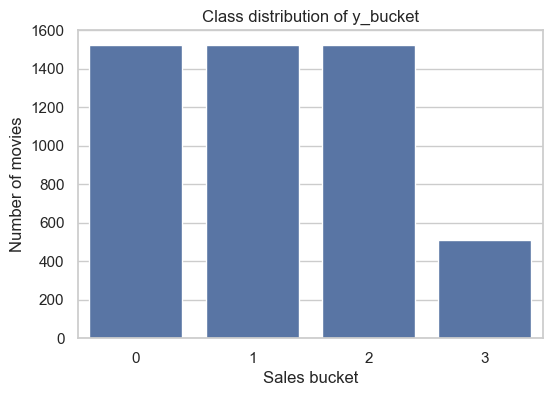

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
#Visual check of class balance

y = df_final_clean['y_bucket']

class_counts = y.value_counts().sort_index()
class_percent = y.value_counts(normalize=True).sort_index() * 100

balance_df = pd.DataFrame({
    'count': class_counts,
    'percentage (%)': class_percent.round(2)
})

balance_df

#Visual check of class balance
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution of y_bucket")
plt.xlabel("Sales bucket")
plt.ylabel("Number of movies")
plt.show()


The class distribution of the target variable was inspected after bucketing worldwide box office revenue. Buckets 0, 1, 2 are approximately balanced, while the blockbuster bucket (bucket 3) is smaller by design. This reflects the natural skew of movie revenues and does not cause a severe class imbalance. Therefore, no resampling techniques were applied.
--> Use stratified splitting not K-folds, as we have more than 4000 row values
--> Use stratified splitting not other methods that handels imbalanced data, such as class weighting, smote or others

dont run the next following until the SVD is done 

In [ ]:
# Dataset splitting into Train, Validation, and Test sets------------------Ahmed

from sklearn.model_selection import train_test_split

X = X_final
y = df_final_clean['y_bucket'].values

# 1) 80% fitting, 20% testing
X_fit, X_test, y_fit, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2) From the 80% fitting: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_fit, y_fit,
    test_size=0.20,          # 20% of the fitting set
    random_state=42,
    stratify=y_fit
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# 3) datasets and objectives for modeling
train_set = (X_train, y_train)
val_set   = (X_val, y_val)
test_set  = (X_test, y_test)

# Verify class balance in each set
def balance(y_part):
    return pd.Series(y_part).value_counts(normalize=True).sort_index().round(3)

print("Train balance:\n", balance(y_train))
print("Val balance:\n", balance(y_val))
print("Test balance:\n", balance(y_test))
